In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "Engine_Temperature": np.random.normal(90, 15, n),
    "RPM": np.random.normal(2500, 500, n),
    "Oil_Pressure": np.random.normal(40, 8, n),
    "Vibration": np.random.normal(3, 1.2, n),
    "Battery_Voltage": np.random.normal(12.5, 0.8, n),
    "Coolant_Temperature": np.random.normal(85, 12, n),
    "Fuel_Consumption": np.random.normal(8, 2, n),
    "Vehicle_Speed": np.random.normal(60, 20, n),
    "Operating_Hours": np.random.uniform(100, 5000, n)
})

# Failure condition
data["Failure"] = (
    (data["Engine_Temperature"] > 110) |
    (data["Oil_Pressure"] < 25) |
    (data["Vibration"] > 5) |
    (data["Battery_Voltage"] < 11) |
    (data["Coolant_Temperature"] > 105)
).astype(int)

data.head()

,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours,Failure
0,97.450712,3199.677718,34.598574,0.710631,11.809205,79.914884,5.771837,75.703702,256.098136,0
1,87.926035,2962.316841,38.843851,1.967538,12.475037,79.559031,6.738138,24.446381,2399.584682,0
2,99.715328,2529.815185,33.660641,2.503673,12.514413,63.452282,6.115880,74.294913,4630.651807,0
3,112.845448,2176.531611,37.536308,5.265225,12.878104,81.038918,6.904008,55.325519,2048.200160,1
4,86.487699,2849.111657,24.851083,3.667864,11.406513,93.793949,7.571699,74.149154,3162.120102,1


In [2]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nFailure Distribution:")
print(data["Failure"].value_counts())

Dataset Shape: (1000, 10)

Column Names:
Index(['Engine_Temperature', 'RPM', 'Oil_Pressure', 'Vibration',
       'Battery_Voltage', 'Coolant_Temperature', 'Fuel_Consumption',
       'Vehicle_Speed', 'Operating_Hours', 'Failure'],
      dtype='object')

Failure Distribution:
Failure
0    751
1    249
Name: count, dtype: int64


In [3]:
data.to_csv("vehicle_health_dataset.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [4]:
import pandas as pd

data = pd.read_csv("vehicle_health_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully!
Shape: (1000, 10)


,Engine_Temperature,RPM,Oil_Pressure,Vibration,Battery_Voltage,Coolant_Temperature,Fuel_Consumption,Vehicle_Speed,Operating_Hours,Failure
0,97.450712,3199.677718,34.598574,0.710631,11.809205,79.914884,5.771837,75.703702,256.098136,0
1,87.926035,2962.316841,38.843851,1.967538,12.475037,79.559031,6.738138,24.446381,2399.584682,0
2,99.715328,2529.815185,33.660641,2.503673,12.514413,63.452282,6.115880,74.294913,4630.651807,0
3,112.845448,2176.531611,37.536308,5.265225,12.878104,81.038918,6.904008,55.325519,2048.200160,1
4,86.487699,2849.111657,24.851083,3.667864,11.406513,93.793949,7.571699,74.149154,3162.120102,1


In [5]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Engine_Temperature   1000 non-null   float64
 1   RPM                  1000 non-null   float64
 2   Oil_Pressure         1000 non-null   float64
 3   Vibration            1000 non-null   float64
 4   Battery_Voltage      1000 non-null   float64
 5   Coolant_Temperature  1000 non-null   float64
 6   Fuel_Consumption     1000 non-null   float64
 7   Vehicle_Speed        1000 non-null   float64
 8   Operating_Hours      1000 non-null   float64
 9   Failure              1000 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 78.3 KB


In [6]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Engine_Temperature     0
RPM                    0
Oil_Pressure           0
Vibration              0
Battery_Voltage        0
Coolant_Temperature    0
Fuel_Consumption       0
Vehicle_Speed          0
Operating_Hours        0
Failure                0
dtype: int64


In [7]:
print("Failure Distribution:")
print(data["Failure"].value_counts())

Failure Distribution:
Failure
0    751
1    249
Name: count, dtype: int64


In [8]:
# Input features
X = data.drop("Failure", axis=1)

# Target variable
y = data["Failure"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
Index(['Engine_Temperature', 'RPM', 'Oil_Pressure', 'Vibration',
       'Battery_Voltage', 'Coolant_Temperature', 'Fuel_Consumption',
       'Vehicle_Speed', 'Operating_Hours'],
      dtype='object')

Target:
Failure

X shape: (1000, 9)
y shape: (1000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [12]:
# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
# Make predictions
y_pred = model.predict(X_test_scaled)

print("Prediction completed!")
print(y_pred[:20])

Prediction completed!
[0 1 1 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.995
Model Accuracy (%): 99.5


In [17]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       150
           1       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



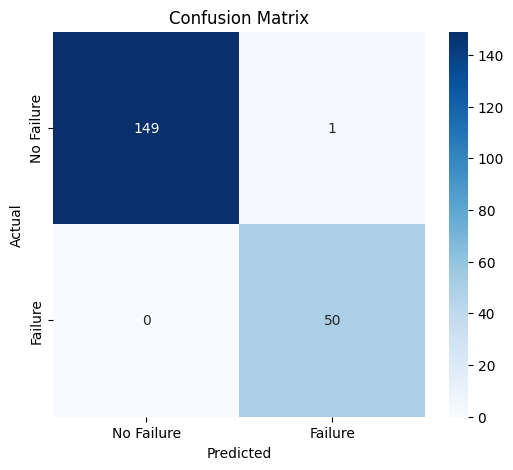

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
0   Engine_Temperature    0.340257
5  Coolant_Temperature    0.189647
3            Vibration    0.166710
4      Battery_Voltage    0.155326
2         Oil_Pressure    0.113707
6     Fuel_Consumption    0.009795
8      Operating_Hours    0.009536
1                  RPM    0.008236
7        Vehicle_Speed    0.006787


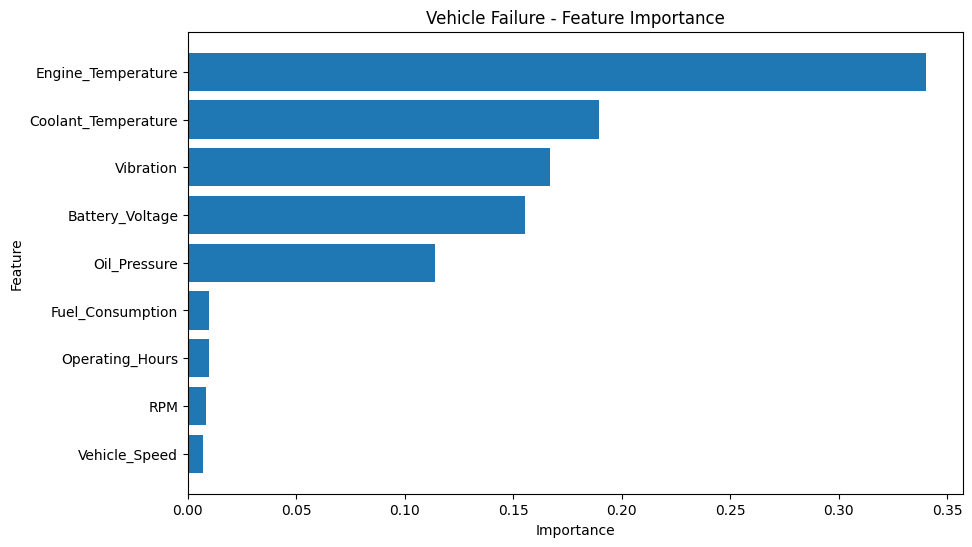

In [20]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Vehicle Failure - Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [21]:
# Calculate failure probability
failure_probability = model.predict_proba(X_test_scaled)[:, 1]

print("Failure Probability:")
print(failure_probability[:10])

Failure Probability:
[0.   1.   1.   0.94 0.14 0.08 0.9  0.98 0.   0.02]


In [22]:
failure_percentage = failure_probability * 100

print("Failure Probability (%):")
print(failure_percentage[:10])

Failure Probability (%):
[  0. 100. 100.  94.  14.   8.  90.  98.   0.   2.]


In [23]:
health_score = 100 - failure_percentage

print("Vehicle Health Score:")
print(health_score[:10])

Vehicle Health Score:
[100.   0.   0.   6.  86.  92.  10.   2. 100.  98.]


In [24]:
def get_status(health):
    if health >= 70:
        return "NORMAL"
    elif health >= 40:
        return "WARNING"
    else:
        return "CRITICAL"

status = [get_status(h) for h in health_score]

print(status[:10])

['NORMAL', 'CRITICAL', 'CRITICAL', 'CRITICAL', 'NORMAL', 'NORMAL', 'CRITICAL', 'CRITICAL', 'NORMAL', 'NORMAL']


In [25]:
results = pd.DataFrame({
    "Failure Probability (%)": failure_percentage,
    "Vehicle Health (%)": health_score,
    "Status": status
})

results.head(10)

,Failure Probability (%),Vehicle Health (%),Status
0,0.0,100.0,NORMAL
1,100.0,0.0,CRITICAL
2,100.0,0.0,CRITICAL
3,94.0,6.0,CRITICAL
4,14.0,86.0,NORMAL
5,8.0,92.0,NORMAL
6,90.0,10.0,CRITICAL
7,98.0,2.0,CRITICAL
8,0.0,100.0,NORMAL
9,2.0,98.0,NORMAL


In [26]:
def get_alert(status):
    if status == "NORMAL":
        return "No maintenance required"
    elif status == "WARNING":
        return "Schedule maintenance soon"
    else:
        return "Immediate maintenance required"

alerts = [get_alert(s) for s in status]

results["Maintenance Alert"] = alerts

results.head(10)

,Failure Probability (%),Vehicle Health (%),Status,Maintenance Alert
0,0.0,100.0,NORMAL,No maintenance required
1,100.0,0.0,CRITICAL,Immediate maintenance required
2,100.0,0.0,CRITICAL,Immediate maintenance required
3,94.0,6.0,CRITICAL,Immediate maintenance required
4,14.0,86.0,NORMAL,No maintenance required
5,8.0,92.0,NORMAL,No maintenance required
6,90.0,10.0,CRITICAL,Immediate maintenance required
7,98.0,2.0,CRITICAL,Immediate maintenance required
8,0.0,100.0,NORMAL,No maintenance required
9,2.0,98.0,NORMAL,No maintenance required


In [27]:
results.to_csv("vehicle_health_predictions.csv", index=False)

print("Final prediction file created successfully!")

Final prediction file created successfully!


In [28]:
vehicle = results.iloc[0]

print("===== VEHICLE HEALTH REPORT =====")
print("Vehicle Health:", round(vehicle["Vehicle Health (%)"], 2), "%")
print("Failure Probability:", round(vehicle["Failure Probability (%)"], 2), "%")
print("Status:", vehicle["Status"])
print("Maintenance Alert:", vehicle["Maintenance Alert"])

===== VEHICLE HEALTH REPORT =====
Vehicle Health: 100.0 %
Failure Probability: 0.0 %
Status: NORMAL
Maintenance Alert: No maintenance required


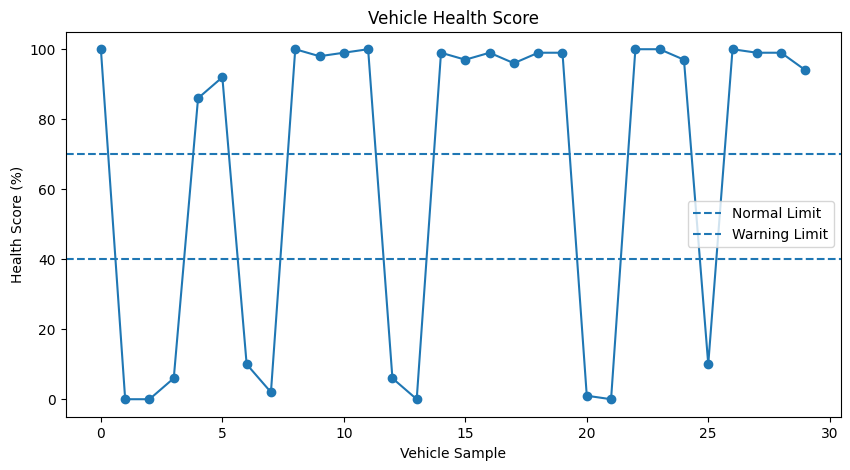

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    results["Vehicle Health (%)"].head(30),
    marker="o"
)

plt.axhline(70, linestyle="--", label="Normal Limit")
plt.axhline(40, linestyle="--", label="Warning Limit")

plt.xlabel("Vehicle Sample")
plt.ylabel("Health Score (%)")
plt.title("Vehicle Health Score")
plt.legend()
plt.show()

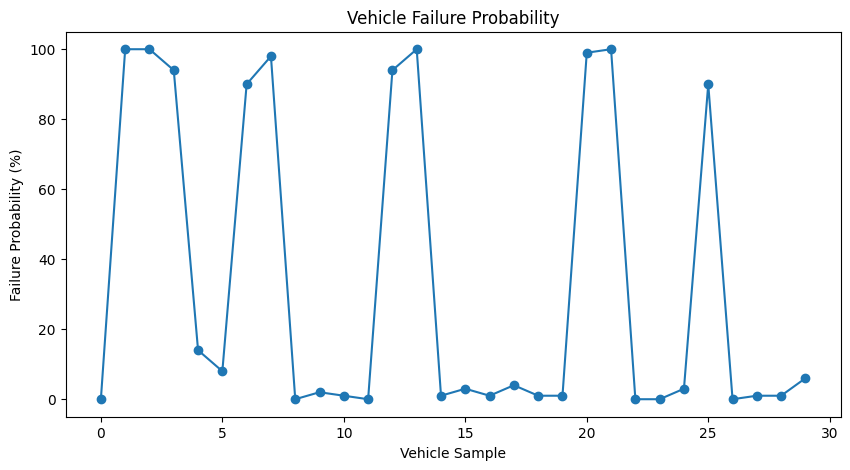

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    results["Failure Probability (%)"].head(30),
    marker="o"
)

plt.xlabel("Vehicle Sample")
plt.ylabel("Failure Probability (%)")
plt.title("Vehicle Failure Probability")

plt.show()

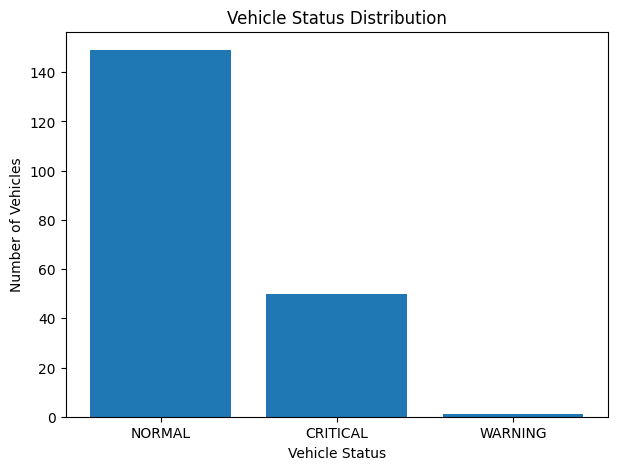

In [31]:
status_counts = results["Status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.xlabel("Vehicle Status")
plt.ylabel("Number of Vehicles")
plt.title("Vehicle Status Distribution")

plt.show()

In [32]:
# Select one vehicle/sample
vehicle_index = 0

vehicle_data = X_test.iloc[vehicle_index]
vehicle_result = results.iloc[vehicle_index]

print("=" * 50)
print("       VEHICLE HEALTH MONITORING REPORT")
print("=" * 50)

print("\n--- Vehicle Parameters ---")
print("Engine Temperature :", round(vehicle_data["Engine_Temperature"], 2))
print("RPM                :", round(vehicle_data["RPM"], 2))
print("Oil Pressure       :", round(vehicle_data["Oil_Pressure"], 2))
print("Vibration          :", round(vehicle_data["Vibration"], 2))
print("Battery Voltage    :", round(vehicle_data["Battery_Voltage"], 2))
print("Coolant Temperature:", round(vehicle_data["Coolant_Temperature"], 2))
print("Fuel Consumption   :", round(vehicle_data["Fuel_Consumption"], 2))
print("Vehicle Speed      :", round(vehicle_data["Vehicle_Speed"], 2))
print("Operating Hours    :", round(vehicle_data["Operating_Hours"], 2))

print("\n--- AI Prediction ---")
print("Vehicle Health     :", round(vehicle_result["Vehicle Health (%)"], 2), "%")
print("Failure Probability:", round(vehicle_result["Failure Probability (%)"], 2), "%")
print("Status             :", vehicle_result["Status"])

print("\n--- Maintenance ---")
print("Alert              :", vehicle_result["Maintenance Alert"])

print("=" * 50)

       VEHICLE HEALTH MONITORING REPORT

--- Vehicle Parameters ---
Engine Temperature : 73.06
RPM                : 2487.9
Oil Pressure       : 37.58
Vibration          : 2.53
Battery Voltage    : 12.04
Coolant Temperature: 80.9
Fuel Consumption   : 8.54
Vehicle Speed      : 43.89
Operating Hours    : 370.57

--- AI Prediction ---
Vehicle Health     : 100.0 %
Failure Probability: 0.0 %
Status             : NORMAL

--- Maintenance ---
Alert              : No maintenance required


In [33]:
print("Top 5 Important Factors:")

print(
    feature_importance.head(5).to_string(index=False)
)

Top 5 Important Factors:
            Feature  Importance
 Engine_Temperature    0.340257
Coolant_Temperature    0.189647
          Vibration    0.166710
    Battery_Voltage    0.155326
       Oil_Pressure    0.113707
